# Figure 4

Generates the eight spatial and quantitative panels used in Fig. 4. All pumping allocations and responses are retained at 1-km Cell resolution.


In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from pyproj import Geod, Transformer
from scipy.interpolate import PchipInterpolator
from shapely.geometry import LineString


def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'src' / 'management' / 'experiments.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate the project root.')


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.management.experiments import PI75_NORMAL_FACTOR, WINDOW_2012, WINDOW_2013, context
from src.management.recovery import scenario_path as recovery_scenario_path

OUT_DIR = ROOT / 'outputs' / 'figures' / 'Fig4'
OUT_DIR.mkdir(parents=True, exist_ok=True)
VOLUME_OUT = OUT_DIR / 'Fig4_leverage_targeted_reduction_cells.png'
BOUNDARY_PATH = ROOT / 'assets' / 'spatial' / 'mrva_boundary.geojson'
RIVER_PATH = ROOT / 'assets' / 'spatial' / 'mississippi_river.gmt'

GRID_CRS = 'EPSG:5070'
LONLAT_CRS = 'EPSG:4326'
EXPORT_DPI = 600

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 0.65,
    'svg.fonttype': 'none',
})

C:\Users\10211\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ctx = context()
allocation_2012 = pd.read_csv(ROOT / 'outputs' / 'MANAGEMENT_2012_2013' / 'equal_volume' / 'drought_leverage_cells.csv.gz')
allocation_2012 = allocation_2012.set_index('grid_id').reindex(ctx.grid_ids)
mean_cell_fraction = allocation_2012['reduction_fraction'].to_numpy(np.float64)
mean_cell_reduction_m3 = allocation_2012['reduction_m3'].to_numpy(np.float64)
if mean_cell_fraction.shape != (len(ctx.grid_ids),):
    raise AssertionError('Incomplete Cell allocation.')
if mean_cell_fraction.min() < 0 or mean_cell_fraction.max() > 0.5 + 1e-7:
    raise AssertionError('The Cell-level 50% cap was exceeded.')
if not np.isfinite(mean_cell_reduction_m3).all():
    raise AssertionError('Cell allocation contains missing values.')

print(f'Allocation scale: 1 km Cell')
print(f'Leverage score scale: 1 km Cell')
print('Ranking: shared mean of five seed-specific Cell scores')
print(f'Actual conserved volume: {mean_cell_reduction_m3.sum() / 1e9:.3f} x 10^9 m3')
print(f'Cells receiving a reduction: {(mean_cell_fraction > 0).sum():,}')
print(f'Cells reduced by 50%: {(mean_cell_fraction >= 0.5 - 1e-7).sum():,}')

Allocation scale: 1 km Cell
Leverage score scale: 1 km Cell
Ranking: shared mean of five seed-specific Cell scores
Actual conserved volume: 3.299 x 10^9 m3
Cells receiving a reduction: 23,990
Cells reduced by 50%: 23,989


In [3]:
grid = ctx.grid.copy()
n_rows = int(grid['row'].max()) + 1
n_cols = int(grid['col'].max()) + 1
rows = grid['row'].to_numpy(dtype=int)
cols = grid['col'].to_numpy(dtype=int)
dx = float(np.median(np.diff(np.sort(grid['x'].unique()))))
dy = float(np.median(np.diff(np.sort(grid['y'].unique()))))
if not (np.isclose(abs(dx), 1000.0) and np.isclose(abs(dy), 1000.0)):
    raise AssertionError('Expected the native 1 km grid.')

x_origin = float(np.median(grid['x'] - grid['col'] * dx))
y_origin = float(np.median(grid['y'] - grid['row'] * dy))
x_edges = x_origin + (np.arange(n_cols + 1) - 0.5) * dx
y_edges = y_origin + (np.arange(n_rows + 1) - 0.5) * dy
transformer = Transformer.from_crs(GRID_CRS, LONLAT_CRS, always_xy=True)
edge_xx, edge_yy = np.meshgrid(x_edges, y_edges)
lon_edges, lat_edges = transformer.transform(edge_xx, edge_yy)
map_extent = (
    float(np.nanmin(lon_edges)), float(np.nanmax(lon_edges)),
    float(np.nanmin(lat_edges)), float(np.nanmax(lat_edges)),
)

fraction_raster = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
fraction_raster[rows, cols] = (100 * mean_cell_fraction).astype(np.float32)
volume_raster = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
volume_raster[rows, cols] = (mean_cell_reduction_m3 / 1e6).astype(np.float32)

boundary = gpd.read_file(BOUNDARY_PATH).to_crs(LONLAT_CRS)
mrva_polygon = boundary.geometry.union_all() if hasattr(boundary.geometry, 'union_all') else boundary.unary_union
mrva_boundary = mrva_polygon.boundary

In [4]:
def read_gmt_segments(path: Path) -> list[np.ndarray]:
    segments, current = [], []
    for line in path.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith('>'):
            if current:
                segments.append(np.asarray(current, dtype=float))
                current = []
            continue
        lon, lat = line.split()[:2]
        current.append((float(lon), float(lat)))
    if current:
        segments.append(np.asarray(current, dtype=float))
    return segments


def plot_line_geometry(ax, geometry, **kwargs) -> None:
    if geometry is None or geometry.is_empty:
        return
    if geometry.geom_type == 'LineString':
        x, y = geometry.xy
        ax.plot(np.asarray(x), np.asarray(y), **kwargs)
    elif geometry.geom_type in {'MultiLineString', 'GeometryCollection'}:
        for part in geometry.geoms:
            plot_line_geometry(ax, part, **kwargs)
    elif geometry.geom_type == 'Polygon':
        plot_line_geometry(ax, geometry.boundary, **kwargs)
    elif geometry.geom_type == 'MultiPolygon':
        for part in geometry.geoms:
            plot_line_geometry(ax, part.boundary, **kwargs)


def draw_scale_bar(ax, length_km: float = 100, anchor=(0.60, 0.055)) -> None:
    geod = Geod(ellps='WGS84')
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    lon0 = xmin + anchor[0] * (xmax - xmin)
    lat0 = ymin + anchor[1] * (ymax - ymin)
    lon1, _, _ = geod.fwd(lon0, lat0, 90, length_km * 1000)
    width = lon1 - lon0
    height = 0.010 * (ymax - ymin)
    for index, color in enumerate(['#111111', '#FFFFFF']):
        ax.add_patch(Rectangle(
            (lon0 + index * width / 2, lat0), width / 2, height,
            facecolor=color, edgecolor='#111111', linewidth=0.45,
            clip_on=False, zorder=8,
        ))
    ax.text(
        lon0 + width / 2, lat0 + 2 * height, f'{int(length_km)} km',
        ha='center', va='bottom', fontsize=7.5, fontweight='bold',
        color='#111111', clip_on=False, zorder=9,
        path_effects=[pe.withStroke(linewidth=1.6, foreground='white')],
    )


river_segments = read_gmt_segments(RIVER_PATH)

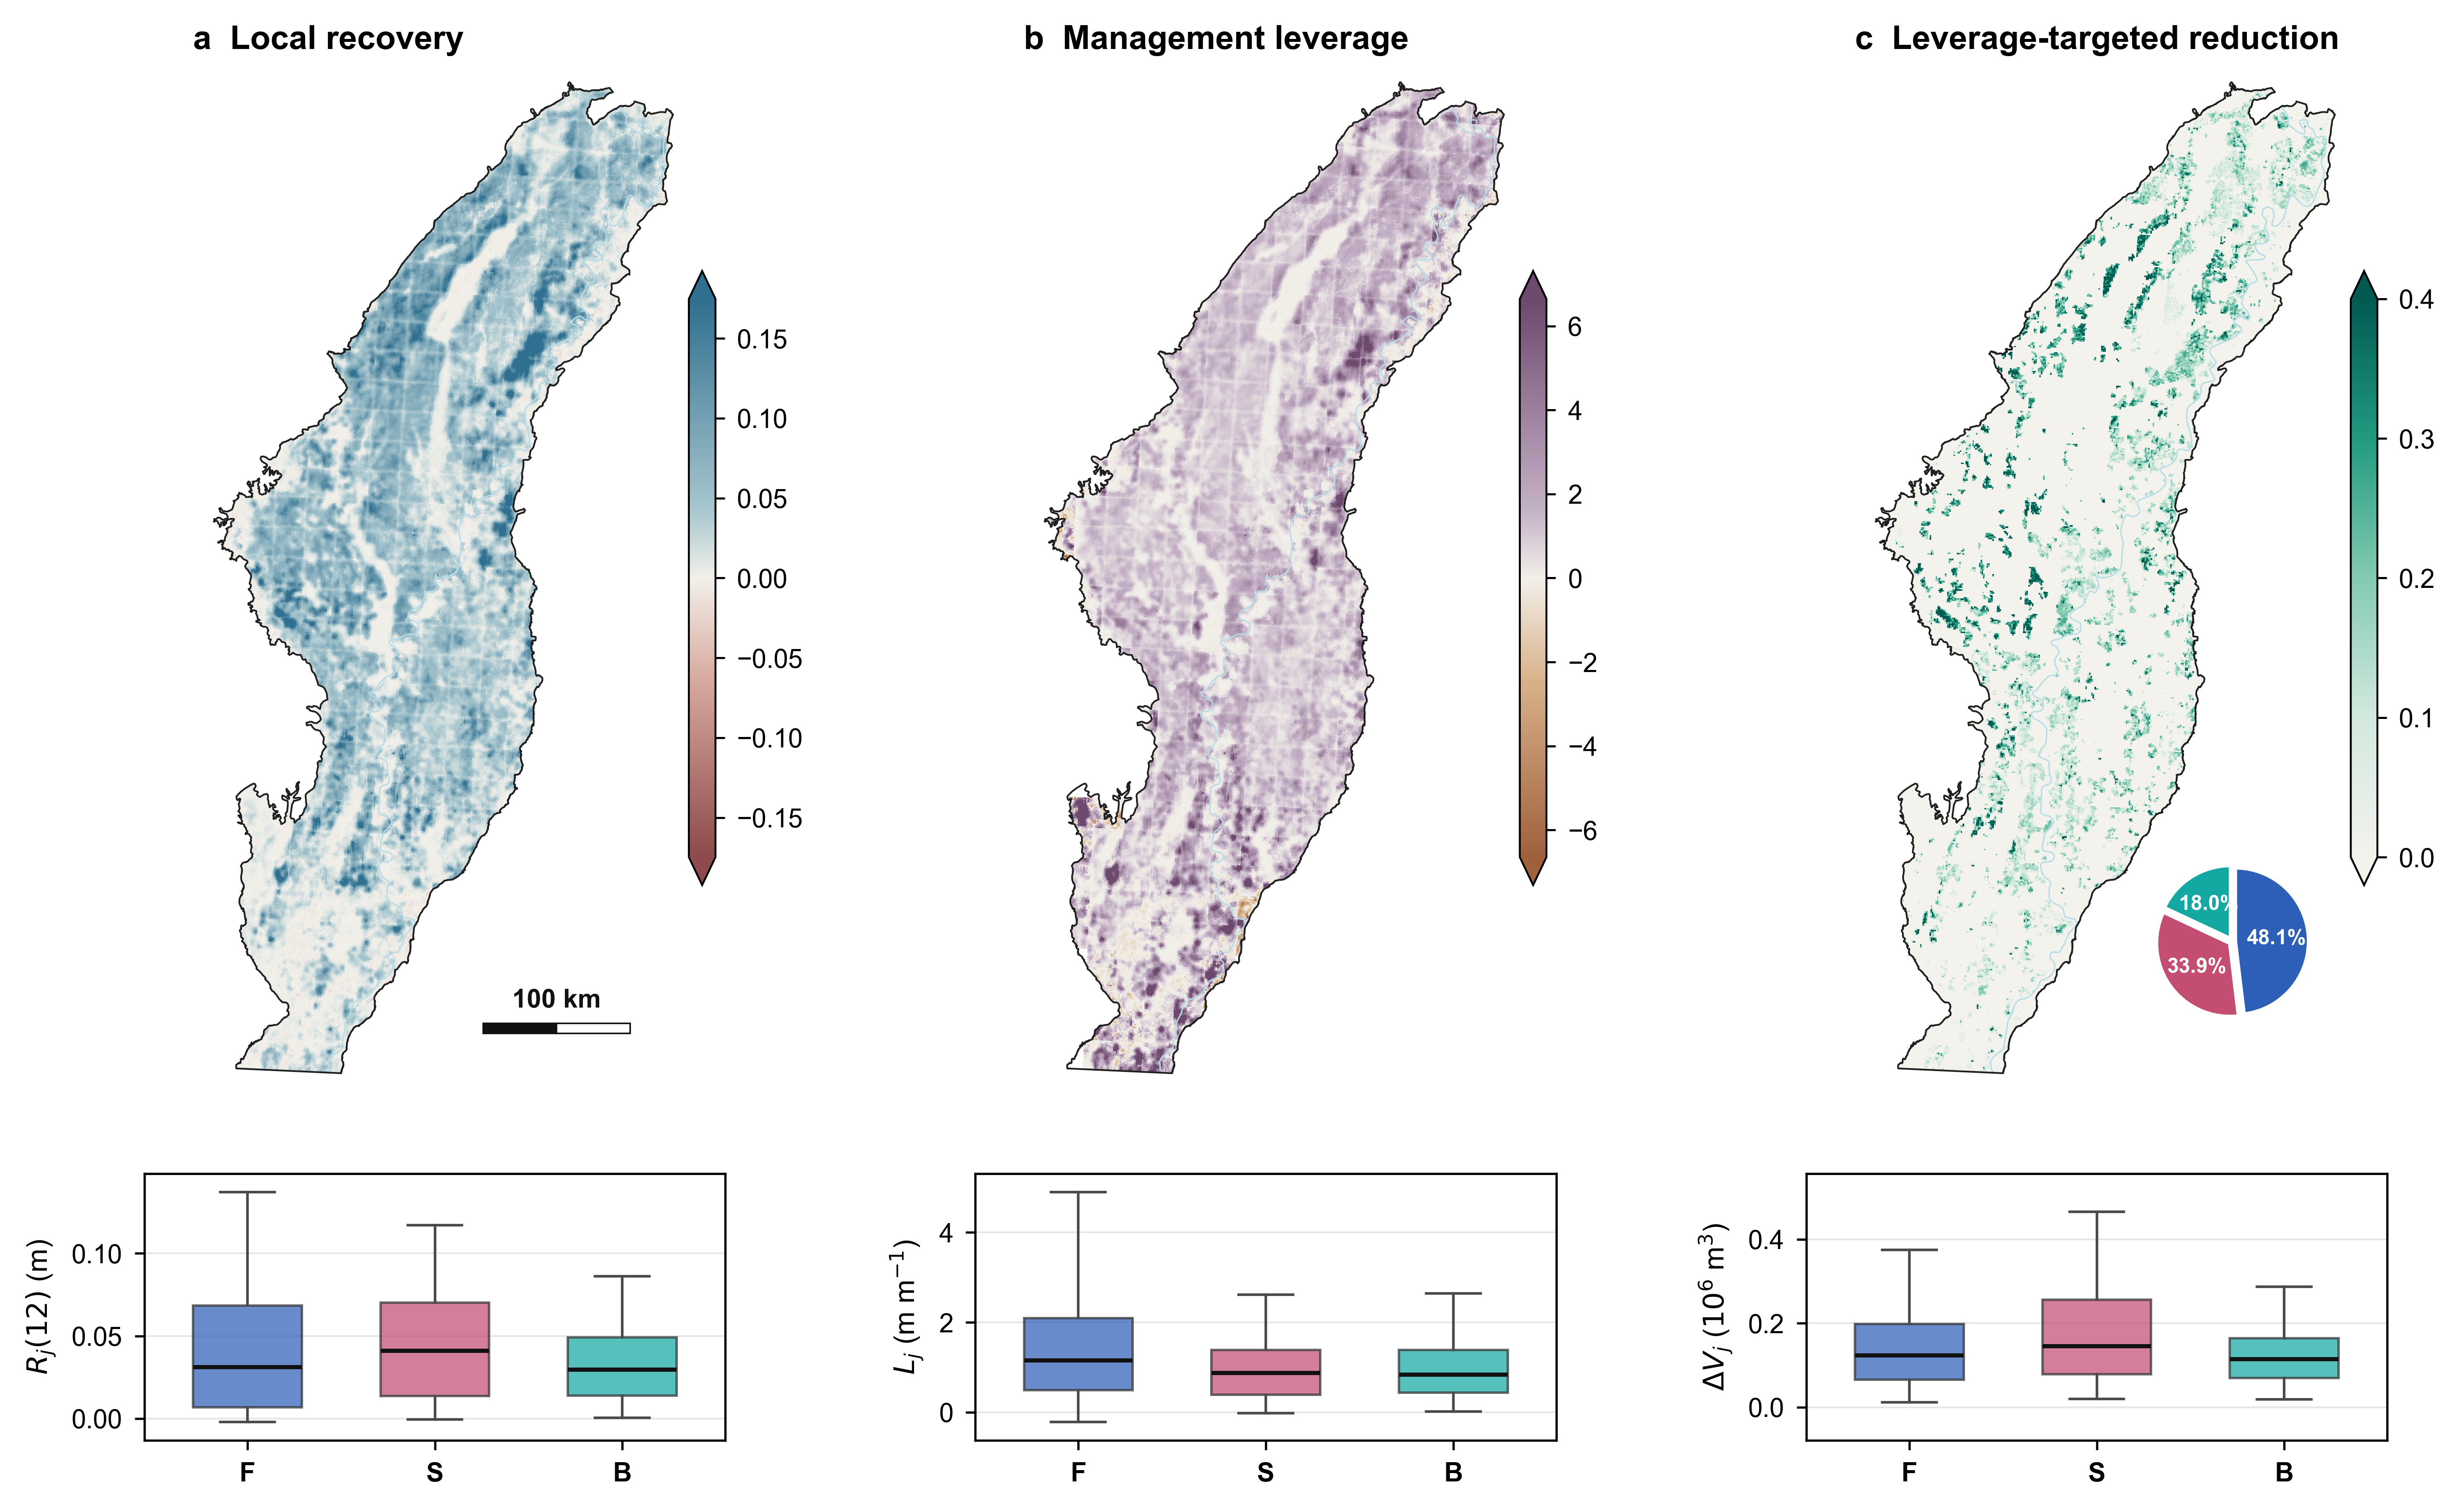

Saved: outputs\figures\Fig4\Fig4_leverage_targeted_reduction_cells.png


In [5]:
CELL_METRICS_PATH = ROOT / 'outputs' / 'MANAGEMENT_2012_2013' / 'local_response' / 'cell_metrics.csv.gz'
cell_metrics = pd.read_csv(CELL_METRICS_PATH)
ordered_metrics = cell_metrics.set_index('grid_id').reindex(grid['grid_id'].to_numpy())
if ordered_metrics[['own_unit_response_dec2012_m', 'management_leverage']].isna().all(axis=0).any():
    raise ValueError('FigS22 Cell metrics do not align with the Fig4 grid.')

local_recovery_raster = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
local_recovery_raster[rows, cols] = ordered_metrics['own_unit_response_dec2012_m'].to_numpy(np.float32)
leverage_raster = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
leverage_raster[rows, cols] = ordered_metrics['management_leverage'].to_numpy(np.float32)

local_recovery_cmap = LinearSegmentedColormap.from_list(
    'local_recovery_manuscript',
    [
        (0.00, '#8E4A4C'),
        (0.32, '#D8AAA0'),
        (0.50, '#F2F0EA'),
        (0.62, '#A9C7CF'),
        (1.00, '#2F6F8F'),
    ],
    N=256,
)
management_leverage_cmap = LinearSegmentedColormap.from_list(
    'management_leverage_manuscript',
    [
        (0.00, '#9F613C'),
        (0.32, '#D9B38C'),
        (0.50, '#F2F0EA'),
        (0.62, '#C5B2C7'),
        (1.00, '#6E496E'),
    ],
    N=256,
)
reduction_cmap = LinearSegmentedColormap.from_list(
    'leverage_reduction', ['#F3F2ED', '#D2E9DE', '#83CAB1', '#209B80', '#005A50'], N=256,
)
local_recovery_cmap.set_bad('#FFFFFF')
management_leverage_cmap.set_bad('#FFFFFF')
reduction_cmap.set_bad('#FFFFFF')


def robust_centered_norm(raster, lower=0.01, upper=0.99):
    finite = np.asarray(raster)[np.isfinite(raster)]
    q_low, q_high = np.quantile(finite, [lower, upper])
    bound = max(abs(float(q_low)), abs(float(q_high)))
    return TwoSlopeNorm(vmin=-bound, vcenter=0.0, vmax=bound)


def style_map_axis(ax, add_scale_bar=False):
    for segment in river_segments:
        if len(segment) >= 2:
            clipped = LineString(segment).intersection(mrva_polygon)
            plot_line_geometry(ax, clipped, color='#B7DDE8', lw=0.42, alpha=0.95, zorder=3)
    plot_line_geometry(ax, mrva_boundary, color='#1F1F1F', lw=0.50, zorder=4)
    ax.set_xlim(map_extent[0], map_extent[1])
    ax.set_ylim(map_extent[2], map_extent[3])
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    mean_lat = 0.5 * (map_extent[2] + map_extent[3])
    ax.set_aspect(1.0 / np.cos(np.deg2rad(mean_lat)))
    if add_scale_bar:
        draw_scale_bar(ax)


CLASS_LABELS_PATH = ROOT / 'outputs' / 'RECON_MAIN_2011_2023' / 'metrics' / 'clustering' / 'cluster_labels.csv'
class_labels = pd.read_csv(
    CLASS_LABELS_PATH, usecols=['grid_id', 'valid_for_clustering', 'response_class'],
)
class_metrics = pd.DataFrame({
    'grid_id': grid['grid_id'].to_numpy(),
    'local_recovery': ordered_metrics['own_unit_response_dec2012_m'].to_numpy(float),
    'management_leverage': ordered_metrics['management_leverage'].to_numpy(float),
    'reduced_pumping': mean_cell_reduction_m3 / 1e6,
}).merge(class_labels, on='grid_id', how='left', validate='one_to_one')
class_metrics = class_metrics.loc[
    class_metrics['valid_for_clustering'].fillna(False)
    & class_metrics['response_class'].notna()
].copy()
CLASS_ORDER = ['Fast recovery', 'Slow recovery', 'Buffered']
CLASS_SHORT = {'Fast recovery': 'F', 'Slow recovery': 'S', 'Buffered': 'B'}
CLASS_COLORS = {'Fast recovery': '#2D5FB8', 'Slow recovery': '#C44E72', 'Buffered': '#13A8A2'}

panel_specs = [
    ('a  Local recovery', local_recovery_raster, local_recovery_cmap, robust_centered_norm(local_recovery_raster),
     None, 'local_recovery', r'$R_j(12)$ (m)'),
    ('b  Management leverage', leverage_raster, management_leverage_cmap, robust_centered_norm(leverage_raster),
     None, 'management_leverage', r'$L_j$ (m m$^{-1}$)'),
    ('c  Leverage-targeted reduction', volume_raster, reduction_cmap, Normalize(vmin=0, vmax=0.4),
     [0, 0.1, 0.2, 0.3, 0.4], 'reduced_pumping', r'$\Delta V_j$ ($10^6$ m$^3$)'),
]
fig = plt.figure(figsize=(9.6, 6.25), dpi=EXPORT_DPI)
layout = fig.add_gridspec(2, 3, height_ratios=[4.8, 1.25], hspace=0.13, wspace=0.43)
map_axes = [fig.add_subplot(layout[0, index]) for index in range(3)]
box_axes = [fig.add_subplot(layout[1, index]) for index in range(3)]
for index, (ax, box_ax, (title, raster, cmap, norm, ticks, metric, ylabel)) in enumerate(
    zip(map_axes, box_axes, panel_specs)
):
    image = ax.pcolormesh(
        lon_edges, lat_edges, raster, cmap=cmap, norm=norm,
        shading='flat', rasterized=True, zorder=1,
    )
    style_map_axis(ax, add_scale_bar=(index == 0))
    ax.set_title(title, loc='left', fontsize=9.5, fontweight='bold', pad=5)
    colorbar_ax = ax.inset_axes([1.025, 0.20, 0.055, 0.60])
    cbar = fig.colorbar(image, cax=colorbar_ax, orientation='vertical', extend='both')
    if ticks is not None:
        cbar.set_ticks(ticks)
    cbar.ax.tick_params(length=2.6, width=0.6, labelsize=7.5)
    cbar.outline.set_linewidth(0.55)

    class_values = []
    for class_name in CLASS_ORDER:
        values = class_metrics.loc[
            class_metrics['response_class'] == class_name, metric
        ].dropna().to_numpy(float)
        if metric == 'reduced_pumping':
            values = values[values > 0.0]
        class_values.append(values)
    boxplot = box_ax.boxplot(
        class_values, positions=np.arange(1, 4), widths=0.58, patch_artist=True,
        whis=(5, 95), showfliers=False,
        medianprops={'color': '#111111', 'linewidth': 1.2},
        whiskerprops={'color': '#4A4A4A', 'linewidth': 0.75},
        capprops={'color': '#4A4A4A', 'linewidth': 0.75},
    )
    for class_name, patch in zip(CLASS_ORDER, boxplot['boxes']):
        patch.set_facecolor(CLASS_COLORS[class_name])
        patch.set_edgecolor('#333333')
        patch.set_linewidth(0.7)
        patch.set_alpha(0.72)
    box_ax.set_xlim(0.45, 3.55)
    lower_whisker = min(np.quantile(values, 0.05) for values in class_values)
    upper_whisker = max(np.quantile(values, 0.95) for values in class_values)
    whisker_span = upper_whisker - lower_whisker
    padding = (0.20 if metric == 'reduced_pumping' else 0.08) * whisker_span
    box_ax.set_ylim(lower_whisker - padding, upper_whisker + padding)
    box_ax.set_xticks(np.arange(1, 4), [CLASS_SHORT[name] for name in CLASS_ORDER], fontweight='bold')
    box_ax.set_ylabel(ylabel, fontsize=8.2)
    box_ax.tick_params(direction='out', length=2.8, width=0.65, labelsize=7.5)
    box_ax.grid(axis='y', color='#E6E6E6', linewidth=0.5, zorder=0)
    for spine in box_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.65)
    if metric == 'reduced_pumping':
        total_reduction = float(class_metrics['reduced_pumping'].sum())
        volume_shares = [
            100.0 * class_metrics.loc[
                class_metrics['response_class'] == class_name, 'reduced_pumping'
            ].sum() / total_reduction
            for class_name in CLASS_ORDER
        ]
        pie_ax = ax.inset_axes([0.59, 0.010, 0.38, 0.27])
        pie_ax.pie(
            volume_shares, autopct='%1.1f%%', pctdistance=0.56,
            colors=[CLASS_COLORS[class_name] for class_name in CLASS_ORDER],
            startangle=90, counterclock=False, explode=[0.04, 0.04, 0.04],
            labeldistance=0.60,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.1},
            textprops={'color': 'white', 'fontsize': 6.0, 'fontweight': 'bold'},
        )
        pie_ax.set_axis_off()
fig.subplots_adjust(left=0.055, right=0.985, top=0.95, bottom=0.075)
fig.savefig(VOLUME_OUT, dpi=EXPORT_DPI, bbox_inches='tight', pad_inches=0.04, facecolor='white')
plt.show()
print('Saved:', VOLUME_OUT.relative_to(ROOT))

## Fig. 4 map and management panels

Exports the Local recovery, Management leverage, Leverage-guided reduction, management-goal and storage-destination panels separately for figure assembly.


In [6]:
PANEL_STYLE = dict(title=9, label=8, tick=7, annotation=7)
MAP_SIZE = (3.25, 5.15)
QUANT_SIZE = (3.25, 2.55)
SUMMARY_SIZE = (4.35, 3.25)
MANAGEMENT_SIZE = (5.2, 3.5)
TRAJECTORY_SIZE = (SUMMARY_SIZE[0] * 2.5, 3.0)
SUMMARY_STYLE = dict(label=9, tick=8, legend=8.2, annotation=8)
MANAGEMENT_STYLE = dict(label=9, tick=8, legend=8.2, annotation=8)
TRAJECTORY_STYLE = {key: value + 5 for key, value in SUMMARY_STYLE.items()}
FIG4_PALETTE = {
    'neutral': '#4A4A4A',
    'local_blue': '#2F6F8F',
    'drought_terracotta': '#9F613C',
    'leverage_purple': '#6E496E',
    'reduction_teal': '#16857C',
    'unrecovered_rose': '#B8647C',
}
allocation_2013 = pd.read_csv(ROOT / 'outputs' / 'MANAGEMENT_2012_2013' / 'equal_volume' / 'recovery_leverage_cells.csv.gz')
allocation_2013 = allocation_2013.set_index('grid_id').reindex(ctx.grid_ids)
reduction_2013_m3 = allocation_2013['reduction_m3'].to_numpy(float)
volume_2013_raster = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
volume_2013_raster[rows, cols] = (reduction_2013_m3 / 1e6).astype(np.float32)
class_2013 = pd.DataFrame({'grid_id': grid['grid_id'].to_numpy(), 'reduction_m3': reduction_2013_m3}).merge(class_labels, on='grid_id', how='left', validate='one_to_one')
class_2013 = class_2013[class_2013.valid_for_clustering.fillna(False) & class_2013.response_class.notna()]
shares = np.array([class_2013.loc[class_2013.response_class == name, 'reduction_m3'].sum() for name in CLASS_ORDER], dtype=float)
shares = 100 * shares / shares.sum()
monthly = pd.read_csv(ROOT / 'outputs' / 'MANAGEMENT_2012_2013' / 'recovery_outcomes' / 'unrecovered_monthly.csv')
target_strategy = 'Leverage guided'
seed_names = ['seed11', 'seed22', 'seed33', 'seed44', 'seed55']

def save_panel(fig, stem):
    png = OUT_DIR / f'{stem}.png'
    fig.savefig(png, dpi=600, facecolor='white')
    plt.close(fig)
    return png

def standalone_map(letter, title, raster, cmap, norm, ticks, stem, scale_bar=False, pie_shares=None):
    fig, ax = plt.subplots(figsize=MAP_SIZE, dpi=EXPORT_DPI)
    fig.subplots_adjust(left=0.035, right=0.785, bottom=0.025, top=0.945)
    mesh = ax.pcolormesh(lon_edges, lat_edges, raster, cmap=cmap, norm=norm, shading='flat', rasterized=True, zorder=1)
    style_map_axis(ax, add_scale_bar=scale_bar)
    ax.set_title(f'{letter}  {title}', loc='left', fontsize=PANEL_STYLE['title'], fontweight='bold', pad=5)
    cax = fig.add_axes([0.825, 0.235, 0.038, 0.49])
    cbar = fig.colorbar(mesh, cax=cax, orientation='vertical', extend='both')
    cbar.set_ticks(ticks)
    cbar.ax.tick_params(length=2.4, width=0.6, labelsize=PANEL_STYLE['tick'])
    cbar.outline.set_linewidth(0.6)
    if pie_shares is not None:
        pie_ax = ax.inset_axes([0.00, 0.005, 0.44, 0.25])
        pie_ax.pie(pie_shares, colors=[CLASS_COLORS[name] for name in CLASS_ORDER], startangle=90, counterclock=False,
                   explode=[0.025] * 3, autopct='%1.0f%%', pctdistance=0.58,
                   wedgeprops={'edgecolor': 'white', 'linewidth': 0.8},
                   textprops={'color': 'white', 'fontsize': 6.0, 'fontweight': 'bold'})
        pie_ax.set_axis_off()
    return save_panel(fig, stem)

standalone_map('A', 'Local recovery', local_recovery_raster, local_recovery_cmap,
               robust_centered_norm(local_recovery_raster), [-0.15, 0, 0.15], 'Fig4a_local_recovery')
standalone_map('B', 'Management leverage', leverage_raster, management_leverage_cmap,
               robust_centered_norm(leverage_raster), [-6, 0, 6], 'Fig4b_management_leverage')
standalone_map('C', 'Leverage-guided reduction', volume_2013_raster, reduction_cmap,
               Normalize(vmin=0, vmax=0.4), [0, 0.2, 0.4], 'Fig4c_leverage_guided_reduction',
               scale_bar=True, pie_shares=shares)

def standalone_quant(letter, title, stem, left=0.25):
    fig, ax = plt.subplots(figsize=QUANT_SIZE, dpi=EXPORT_DPI)
    fig.subplots_adjust(left=left, right=0.965, bottom=0.25, top=0.84)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.65)
    ax.tick_params(direction='out', length=2.7, width=0.65, pad=2, labelsize=PANEL_STYLE['tick'])
    ax.set_axisbelow(True)
    ax.grid(axis='x', color='#E9E9E9', linewidth=0.45)
    if title:
        ax.set_title(f'{letter}  {title}', loc='left', fontsize=PANEL_STYLE['title'], fontweight='bold', pad=6)
    return fig, ax


def smooth_response(dates, values, points_per_interval=18):
    x = mdates.date2num(pd.to_datetime(dates).to_numpy())
    x_smooth = np.linspace(x.min(), x.max(), (len(x) - 1) * points_per_interval + 1)
    return mdates.num2date(x_smooth), PchipInterpolator(x, np.asarray(values, float))(x_smooth)

fig, ax = standalone_quant('', '', 'Fig4f_storage_destination', left=0.14)
fig.set_size_inches(*MANAGEMENT_SIZE, forward=True)
fig.subplots_adjust(left=0.17, right=0.975, bottom=0.22, top=0.94)
ax.tick_params(labelsize=MANAGEMENT_STYLE['tick'])
initial_idx, _, output_idx = ctx.window_indices(WINDOW_2013)
endpoint_local = int(np.flatnonzero(ctx.months[output_idx] == '2013-10')[0])
history = np.asarray(ctx.wtd[:output_idx[-1] + 1], dtype=float)
valid_drought = ctx.valid_decline & np.isfinite(ctx.pre_wtd) & (ctx.peak_wtd > ctx.pre_wtd)
recovery_fraction = np.clip((ctx.peak_wtd - history[initial_idx]) / (ctx.peak_wtd - ctx.pre_wtd), 0, 1)
unrecovered = valid_drought & (ctx.baseline_t50_index > initial_idx)
unrecovered_order = np.flatnonzero(unrecovered)[np.argsort(recovery_fraction[unrecovered], kind='stable')]
recovered_order = np.flatnonzero(valid_drought & ~unrecovered)[np.argsort(recovery_fraction[valid_drought & ~unrecovered], kind='stable')]
cell_order = np.concatenate([unrecovered_order, recovered_order])
if len(cell_order) != int(valid_drought.sum()):
    raise AssertionError('The cumulative curve must include every drought-affected Cell exactly once.')
curves = []
for seed in seed_names:
    with np.load(recovery_scenario_path('Uniform', 20, seed)) as archive:
        uniform_response = archive['response_m'][endpoint_local].astype(float)
    with np.load(recovery_scenario_path(target_strategy, 20, seed)) as archive:
        guided_response = archive['response_m'][endpoint_local].astype(float)
    extra_storage = (guided_response - uniform_response) * ctx.storage_weights_m2 / 1e6
    curves.append(np.r_[0.0, np.cumsum(extra_storage[cell_order])])
curves = np.asarray(curves)
curve_mean = curves.mean(axis=0)
curve_radius = PI75_NORMAL_FACTOR * curves.std(axis=0, ddof=0)
area_pct = np.linspace(0, 100, len(curve_mean))
ax.fill_between(area_pct, curve_mean - curve_radius, curve_mean + curve_radius, color=FIG4_PALETTE['reduction_teal'], alpha=0.16, linewidth=0, zorder=1)
ax.plot(area_pct, curve_mean, color=FIG4_PALETTE['reduction_teal'], linewidth=1.7, zorder=3)
ax.axhline(0, color=FIG4_PALETTE['neutral'], linestyle='--', linewidth=0.7, alpha=0.72)
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_ylim(-50, 150)
ax.set_yticks([-50, 0, 50, 100, 150])
ax.set_xlabel('Drought-affected area (%)', fontsize=MANAGEMENT_STYLE['label'])
ax.set_ylabel(r'Cumulative storage benefit (m$^3$)', fontsize=MANAGEMENT_STYLE['label'])
ax.text(-0.012, 1.018, r'$\times 10^6$', transform=ax.transAxes, ha='left', va='bottom', fontsize=MANAGEMENT_STYLE['tick'])
ax.grid(False)
ax.grid(axis='y', color='#DEDCD7', linewidth=0.50, alpha=0.72)
save_panel(fig, 'Fig4f_storage_destination')

# A common-window dual-axis view of the two management outcomes.
fig, ax_left = plt.subplots(figsize=TRAJECTORY_SIZE, dpi=EXPORT_DPI)
ax_right = ax_left.twinx()

def monthly_strategy_mean(strategy, metric, scale=1.0):
    rows = []
    for month in sorted(monthly['month'].unique()):
        values = monthly[(monthly.budget == 20) & (monthly.month == month) & (monthly.strategy == strategy)]\
            .set_index('seed').loc[seed_names, metric].to_numpy(float) * scale
        rows.append({'month': pd.Timestamp(month), 'mean': values.mean()})
    return pd.DataFrame(rows).query("month >= '2013-05-01'").reset_index(drop=True)

dual_metrics = [
    (ax_left, 'net_storage_benefit_m3', 1e-9, FIG4_PALETTE['local_blue']),
    (ax_right, 'mean_deficit_avoided_m', 1e3, FIG4_PALETTE['unrecovered_rose']),
]
for axis, metric, scale, color in dual_metrics:
    for strategy, linestyle in [('Uniform', (0, (5, 3))), (target_strategy, '-')]:
        series = monthly_strategy_mean(strategy, metric, scale)
        dates, values = smooth_response(series['month'], series['mean'])
        axis.plot(dates, values, color=color, linewidth=2.25, linestyle=linestyle, zorder=3)

ax_left.set_xlim(pd.Timestamp('2013-05-01'), pd.Timestamp('2014-12-01'))
ax_left.set_ylim(0, 1.75)
ax_left.set_yticks([0, 0.5, 1.0, 1.5])
ax_right.set_ylim(0, 70)
ax_right.set_yticks([0, 20, 40, 60])
ax_left.set_xlabel('Time', fontsize=TRAJECTORY_STYLE['label'])
ax_left.set_ylabel(r'Storage benefit (m$^3$)', color=FIG4_PALETTE['local_blue'], fontsize=TRAJECTORY_STYLE['label'])
ax_left.text(-0.012, 1.018, r'$\times 10^9$', transform=ax_left.transAxes, ha='left', va='bottom', fontsize=TRAJECTORY_STYLE['tick'])
ax_right.set_ylabel('Unrecovered area (mm)', color=FIG4_PALETTE['unrecovered_rose'], fontsize=TRAJECTORY_STYLE['label'])
ax_left.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax_left.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax_left.get_xticklabels(), rotation=35, ha='right')
for axis, color in [(ax_left, FIG4_PALETTE['local_blue']), (ax_right, FIG4_PALETTE['unrecovered_rose'])]:
    axis.tick_params(axis='y', colors=color, direction='out', length=3.0, width=0.7, labelsize=TRAJECTORY_STYLE['tick'])
ax_left.tick_params(axis='x', direction='out', length=3.0, width=0.7, labelsize=TRAJECTORY_STYLE['tick'])
ax_left.set_axisbelow(True)
ax_left.grid(axis='y', color='#DEDCD7', linewidth=0.50, alpha=0.72)
for spine in ax_left.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.75)
for spine in ax_right.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.75)
ax_left.legend([Line2D([0], [0], color='#525252', linewidth=2.25, linestyle=(0, (5, 3))),
                Line2D([0], [0], color='#525252', linewidth=2.25)],
               ['Uniform', 'Leverage-guided'], loc='upper left', frameon=False,
               fontsize=TRAJECTORY_STYLE['legend'], ncol=2, columnspacing=1.2, handlelength=2.6)
fig.subplots_adjust(left=0.090, right=0.900, bottom=0.22, top=0.920)
fig.savefig(OUT_DIR / 'Fig4e_management_goals_dual_axis.png', dpi=600, facecolor='white')
plt.close(fig)

print('Wrote five standalone Fig. 4 panels.')

Wrote five standalone Fig. 4 panels.


## Groundwater-storage trajectories

Compares no reduction with independent 20% Uniform interventions during 2012 and 2013.

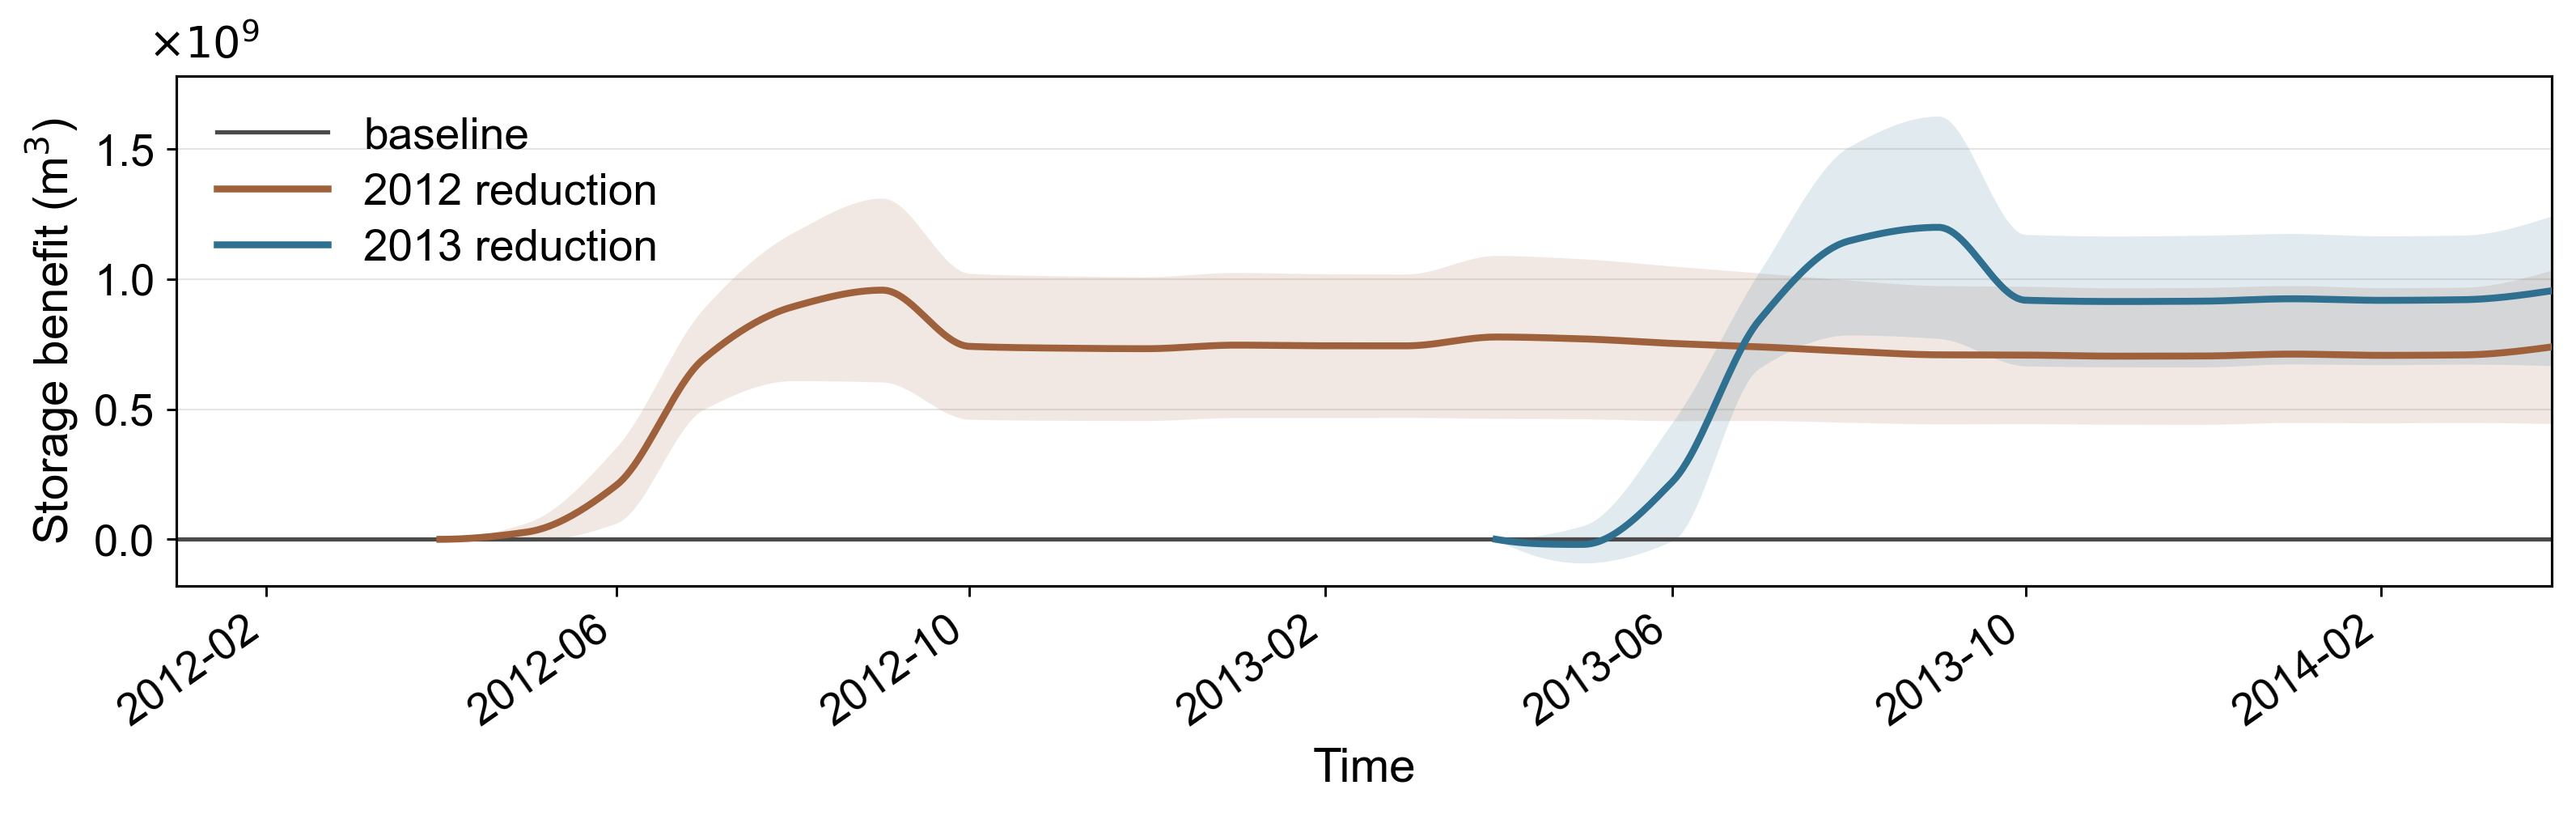

Saved: outputs\figures\Fig4\Fig4_storage_trajectory.png


In [7]:
TRAJECTORY_CACHE = ROOT / 'outputs' / 'MANAGEMENT_2012_2013' / 'equal_volume' / 'uniform_storage_trajectory.csv'
STORAGE_PNG = OUT_DIR / 'Fig4_storage_trajectory.png'
monthly_benefit = pd.read_csv(TRAJECTORY_CACHE, dtype={'seed': str})
monthly_benefit['month'] = pd.to_datetime(monthly_benefit['month'])

plot_indices = ctx.indices('2012-01', '2014-04')
plot_dates = pd.to_datetime(ctx.months[plot_indices])
baseline_storage = np.sum(
    (ctx.pre_wtd[None, :] - np.asarray(ctx.wtd[plot_indices], dtype=np.float64))
    * ctx.storage_weights_m2[None, :], axis=1, dtype=np.float64,
) / 1e9
baseline_lookup = pd.Series(baseline_storage, index=plot_dates)

trajectory_summary = monthly_benefit.groupby(['intervention_period', 'month']).agg(
    mean_benefit=('storage_benefit_m3', 'mean'),
    sd_benefit=('storage_benefit_m3', lambda x: np.std(x, ddof=0)),
    actual_dV_m3=('actual_dV_m3', 'mean'),
).reset_index()
trajectory_summary['mean_benefit'] /= 1e9
trajectory_summary['sd_benefit'] /= 1e9
trajectory_summary['baseline_storage'] = trajectory_summary['month'].map(baseline_lookup)
trajectory_summary['managed_mean'] = trajectory_summary['baseline_storage'] + trajectory_summary['mean_benefit']
trajectory_summary['managed_low'] = trajectory_summary['managed_mean'] - PI75_NORMAL_FACTOR * trajectory_summary['sd_benefit']
trajectory_summary['managed_high'] = trajectory_summary['managed_mean'] + PI75_NORMAL_FACTOR * trajectory_summary['sd_benefit']

def smooth_monthly_curve(dates, values, points_per_interval=24):
    x = mdates.date2num(pd.to_datetime(dates).to_pydatetime())
    x_smooth = np.linspace(x.min(), x.max(), (len(x)-1)*points_per_interval + 1)
    y_smooth = PchipInterpolator(x, np.asarray(values, float))(x_smooth)
    return mdates.num2date(x_smooth), y_smooth

fig, ax = plt.subplots(figsize=TRAJECTORY_SIZE, dpi=300)
ax.axhline(0, color=FIG4_PALETTE['neutral'], linewidth=1.25, label='baseline', zorder=2)
trajectory_styles = {
    WINDOW_2012.name: (FIG4_PALETTE['drought_terracotta'], '2012 reduction'),
    WINDOW_2013.name: (FIG4_PALETTE['local_blue'], '2013 reduction'),
}
for period, (color, label) in trajectory_styles.items():
    data = trajectory_summary[trajectory_summary['intervention_period'] == period].sort_values('month')
    initial_month = pd.Timestamp('2012-04-01') if period == WINDOW_2012.name else pd.Timestamp('2013-04-01')
    dates = np.concatenate([[initial_month.to_datetime64()], data['month'].to_numpy(dtype='datetime64[ns]')])
    benefit_mean = np.concatenate([[0.0], data['mean_benefit'].to_numpy(float)])
    benefit_low = benefit_mean - PI75_NORMAL_FACTOR * np.concatenate([[0.0], data['sd_benefit'].to_numpy(float)])
    benefit_high = benefit_mean + PI75_NORMAL_FACTOR * np.concatenate([[0.0], data['sd_benefit'].to_numpy(float)])
    benefit_dates, smooth_benefit = smooth_monthly_curve(dates, benefit_mean)
    _, smooth_benefit_low = smooth_monthly_curve(dates, benefit_low)
    _, smooth_benefit_high = smooth_monthly_curve(dates, benefit_high)
    reduced_volume = float(data['actual_dV_m3'].mean()) / 1e9
    legend_label = label
    ax.fill_between(benefit_dates, smooth_benefit_low, smooth_benefit_high, color=color, alpha=0.14, linewidth=0, zorder=1)
    ax.plot(benefit_dates, smooth_benefit, color=color, linewidth=2.05, label=legend_label, zorder=3)

ax.set_xlim(plot_dates.min(), plot_dates.max())
ax.set_ylim(-0.18, 1.78)
ax.set_yticks([0.0, 0.5, 1.0, 1.5])
ax.set_ylabel(r'Storage benefit (m$^3$)', fontsize=TRAJECTORY_STYLE['label'], labelpad=4)
ax.text(-0.012, 1.018, r'$\times 10^9$', transform=ax.transAxes, ha='left', va='bottom', fontsize=TRAJECTORY_STYLE['tick'])
ax.set_xlabel('Time', fontsize=TRAJECTORY_STYLE['label'])
ax.legend(loc='upper left', ncol=1, frameon=False, fontsize=TRAJECTORY_STYLE['legend'], handlelength=2.5, labelspacing=0.35)
ax.set_axisbelow(True)
ax.grid(axis='y', color='#DEDCD7', linewidth=0.50, alpha=0.72)
for spine in ax.spines.values():
    spine.set_visible(True); spine.set_linewidth(0.75)
ax.tick_params(direction='out', length=3.0, width=0.7, labelsize=TRAJECTORY_STYLE['tick'])
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
fig.subplots_adjust(left=0.090, right=0.990, bottom=0.22, top=0.920)
fig.savefig(STORAGE_PNG, dpi=600, facecolor='white')
plt.show()
print('Saved:', STORAGE_PNG.relative_to(ROOT))

## Drought-deficit offset

Shows how much of the December 2012 storage deficit is offset by equal pumping-reduction budgets.

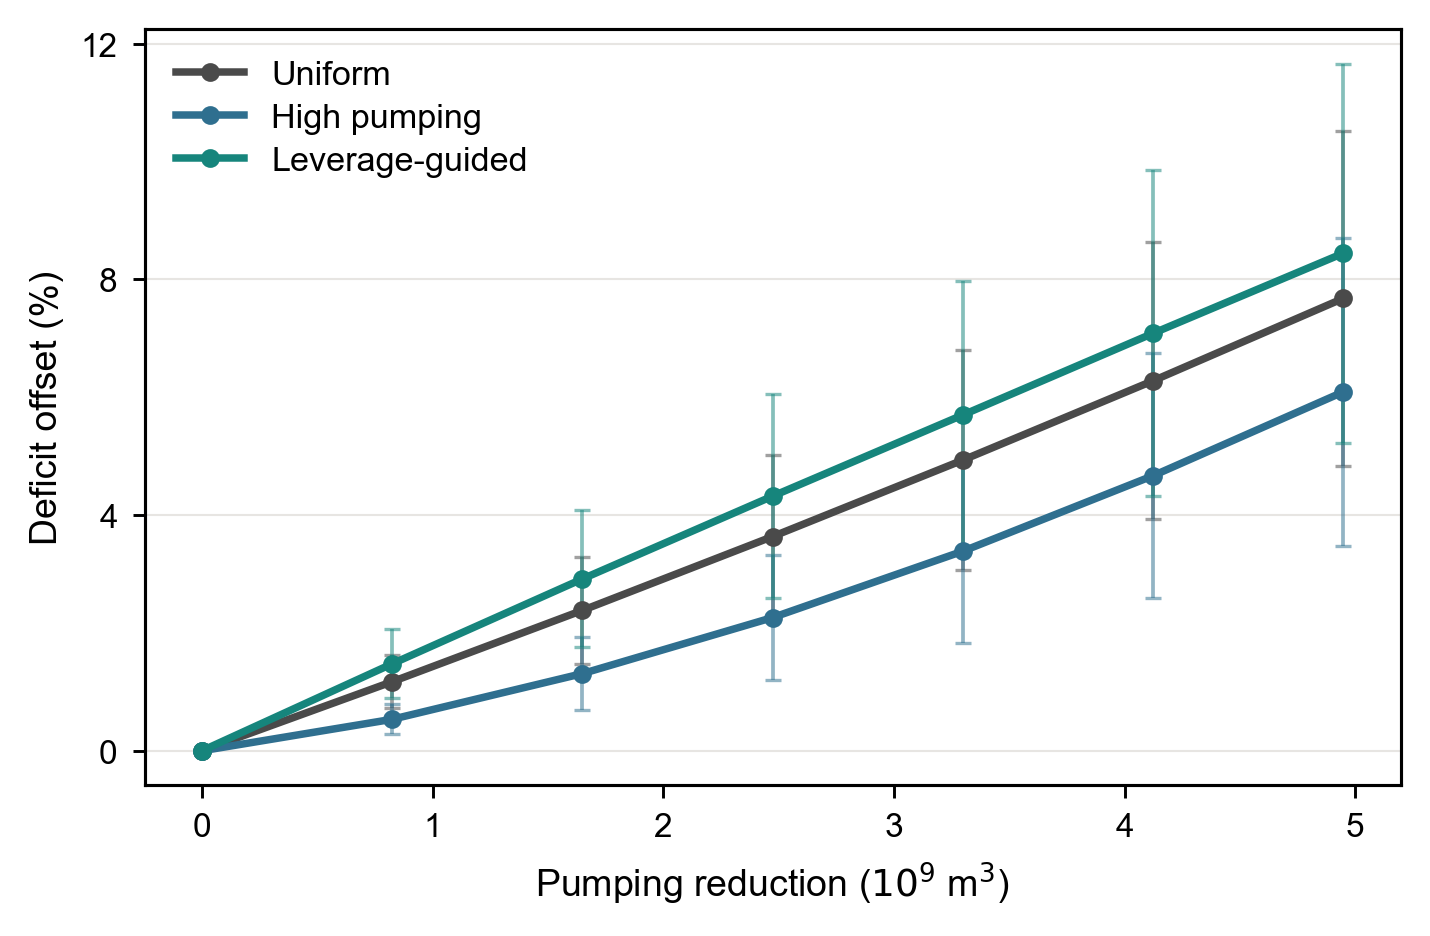

Saved: outputs\figures\Fig4\Fig4_drought_deficit_offset.png


In [8]:
OFFSET_CSV = ROOT / 'outputs' / 'MANAGEMENT_2012_2013' / 'equal_volume' / 'drought_deficit_offset.csv'
OFFSET_PNG = OUT_DIR / 'Fig4_drought_deficit_offset.png'
offset = pd.read_csv(OFFSET_CSV)
offset = offset.loc[offset['budget_nominal'] <= 30].copy()

strategy_colors = {
    'Uniform': FIG4_PALETTE['neutral'],
    'High pumping': FIG4_PALETTE['local_blue'],
    'Leverage guided': FIG4_PALETTE['reduction_teal'],
}
strategy_labels = {
    'Uniform': 'Uniform',
    'High pumping': 'High pumping',
    'Leverage guided': 'Leverage-guided',
}

fig, ax = plt.subplots(figsize=MANAGEMENT_SIZE, dpi=300)
for strategy in strategy_colors:
    data = offset.loc[offset['strategy'] == strategy]
    summary = data.groupby('budget_nominal', sort=True).agg(
        actual_dV_m3=('actual_dV_m3', 'mean'),
        mean_offset=('fraction_offset', 'mean'),
        sd_offset=('fraction_offset', lambda values: np.std(values, ddof=0)),
    ).reset_index()
    x = summary['actual_dV_m3'].to_numpy(float) / 1e9
    y = 100.0 * summary['mean_offset'].to_numpy(float)
    radius = 100.0 * PI75_NORMAL_FACTOR * summary['sd_offset'].to_numpy(float)
    color = strategy_colors[strategy]
    ax.errorbar(x, y, yerr=radius, fmt='none', ecolor=color, elinewidth=0.9,
                capsize=2.0, capthick=0.8, alpha=0.52, zorder=1)
    ax.plot(x, y, color=color, linewidth=1.8, marker='o', markersize=3.5,
            label=strategy_labels[strategy], zorder=2)

ax.set_xlabel(r'Pumping reduction ($10^9$ m$^3$)', fontsize=MANAGEMENT_STYLE['label'])
ax.set_ylabel('Deficit offset (%)', fontsize=MANAGEMENT_STYLE['label'])
ax.set_yticks([0, 4, 8, 12])
ax.legend(loc='upper left', frameon=False, fontsize=MANAGEMENT_STYLE['legend'], handlelength=2.0, labelspacing=0.35)
ax.set_axisbelow(True)
ax.grid(axis='y', color='#DEDCD7', linewidth=0.50, alpha=0.72, zorder=0)
ax.tick_params(direction='out', length=3.0, width=0.7, labelsize=MANAGEMENT_STYLE['tick'])
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.75)
fig.subplots_adjust(left=0.17, right=0.975, bottom=0.22, top=0.94)
fig.savefig(OFFSET_PNG, dpi=600, facecolor='white')
plt.show()
print('Saved:', OFFSET_PNG.relative_to(ROOT))